In [15]:
import xhermes
from xhermes.selectors import selector_poloidal, selector_radial, selector_2d
from xhermes.plotting import plot_selection
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Introduction / summary
This notebook introduces the basics of region selection in xHermes. Currently, only 2D regions and boundaries are supported. In the near-future, tools for selecting radial and poloidal cell rings will be added.

There are tools to return indexers (slices or integer arrays) that allow you to slice the dataset:
- selector_poloidal
- selector_radial
- selector_2d

`selector_2d` is the most useful, as it returns indexers for both the poloidal and radial directions at once, and has a few useful helper features. You can use the same syntax to plot the selection in `plot_selection`.

The `selector_2d` syntax can also be used to perform the actual slicing of a dataset or dataarray, e.g. `ds.select_region("domain", "outer_sol")` or `ds["Te"].select_region("domain", "outer_sol")`.


# Read dataset and select the final time slice
Replace the paths with your own simulation

In [16]:
ds = xhermes.open(
    r"/home/mike/work/cases/mastu2d/m9ax-10core_perftest",  ## Replace with your path to 1D-threshold solution
    gridfilepath = "/home/mike/work/cases/mu1af6-tunepuff.nc",
    keep_yboundaries=True,
    keep_xboundaries=True,
    geometry="toroidal"
)

ds = ds.bout.final_time()

# Poloidal selections
Use `selector_poloidal` to return a slice or integer array defining a poloidal location.
A complete list of locations is in the test of this function, /tests/test_selectors.py.

Some notes on convention:
- "upper" and "lower" midplane refer to the sides of the cell edge exactly at the midplane.
- "extra", e.g. "inner_lower_sol_extra", refers to a single leg SOL slice which extends one cell beyond the midplane (so you can interpolate exactly onto the midplane if required)
- "guards" includes guard cells. If "guards" is not present in the name, guards are never present. Both guard cells are included.

Example:

In [17]:
selector_poloidal(ds, "outer_upper_sol")

slice(46, 76, None)

# Radial selections
Use `selector_radial` to return a slice or integer array defining a radial location. 
The names `xlow` and `xup` refer to the direction towards the start and end of the radial index, so towards the core/pfr and SOL, respecitvely.

The following radial regions are supported:
- domain (excluding guards)
- domain_guards
- boundary_xlow
- boundary_guard_xlow
- boundary_xup
- boundary_guard_xup

Example:

In [18]:
selector_radial(ds, "boundary_xup")

37

# 2D selections

`selector_2d` combines poloidal and radial selections with some extra features:
- Supports radial region `boundary` which automatically resolves to `xup`/`xlow`
- Raises exceptions for invalid combinations (e.g. selecting guards if none present, or xlow radial boundary for SOL poloidal region)
Example:

In [19]:
selector_2d(ds, "boundary", "outer_upper_sol")

(37, slice(46, 76, None))

# Visualising selections
Use `plot_selection` to visualise the selection on both the logical and poloidal grid as selected by `select_2d`.
By default, it takes the name of the radial and poloidal regions. You can override this
and provide a custom selection slice/array instead.

Examples:

#### Example: plotting the outer upper SOL boundary

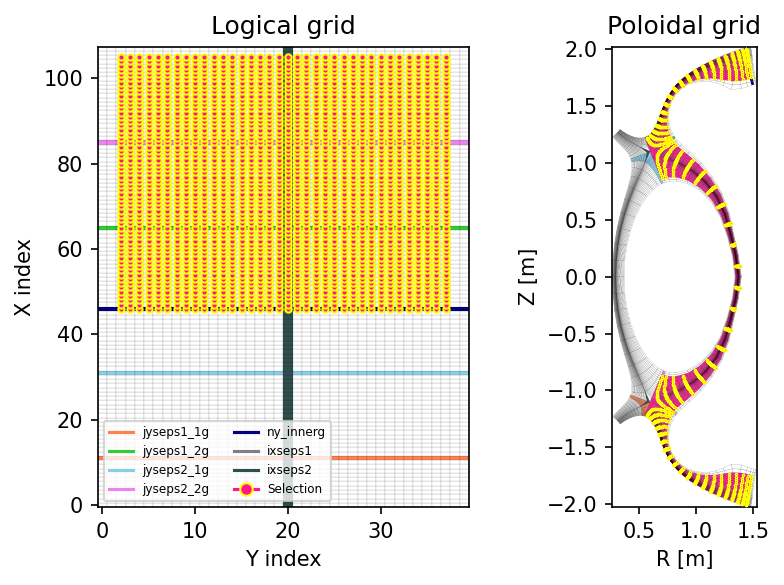

In [20]:
plot_selection(ds, "domain", "outer_sol")

### Example: plotting a custom region

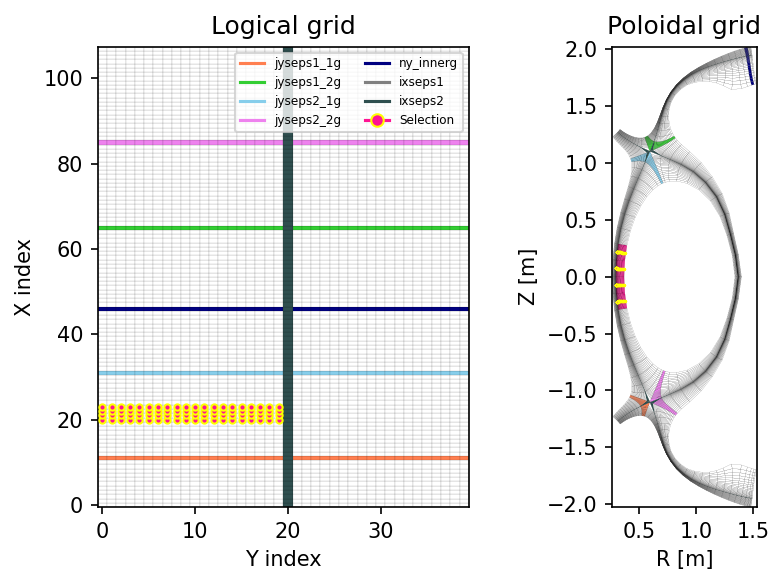

In [21]:
plot_selection(ds, custom_selection=(slice(0,20), slice(20, 24)))

# Using selections to get data

You can use the same selection syntax to slice the dataset using `ds.select_region(radial_region, poloidal_region)`. You can also do this on an individual `DataArray`, e.g. `ds["Te"].select_region(radial_region, poloidal_region)`.

### NOTE:
Note that `select_poloidal`, `select_radial` and `select_2d` return selection indices/slices, while `ds.select_region` returns the sliced dataset.

#### Example: plotting density on the outer lower target

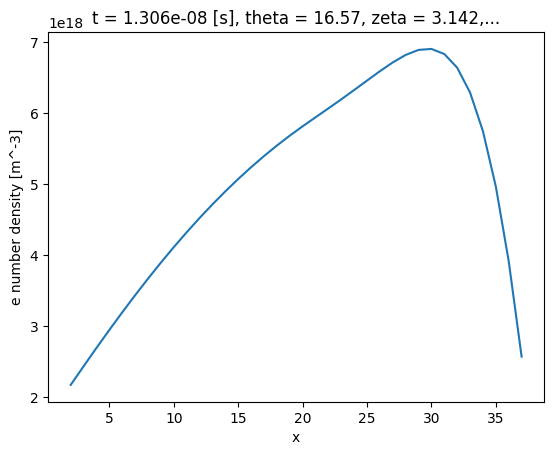

In [22]:
ds_outer_lower_target = ds.hermes.select_region("domain", "outer_lower_target")
ds_outer_lower_target["Ne"].bout.final_time().plot()

#### Example: 2D plot of density on a custom selection

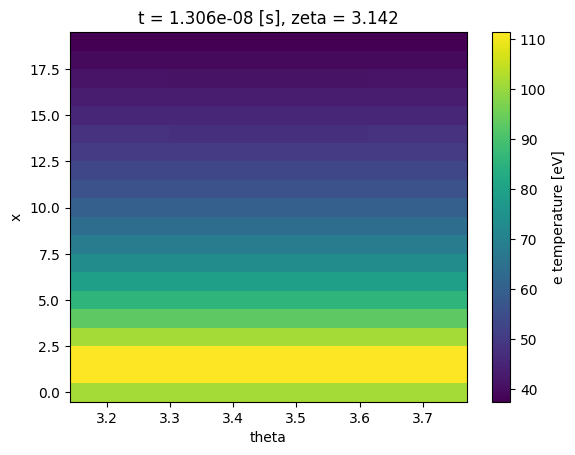

In [23]:
custom_region = ds.hermes.select_region(custom_selection=(slice(0,20), slice(20, 24)))
custom_region["Te"].plot()